#### Install dependencies

In [ ]:
!pip install ultralytics mlflow python-dotenv -q

In [ ]:
!pip install mlflow dagshub

#### Preparing the dataset

In [ ]:
import shutil, os
os.chdir('/content/drive/MyDrive/AlgerPlate Project')

In [ ]:
import os, dagshub, mlflow
#token = dagshub.auth.get_token()

In [ ]:
from google.colab import userdata

os.environ['MLFLOW_TRACKING_URI']      = ''
os.environ['MLFLOW_TRACKING_USERNAME'] = ''
os.environ['MLFLOW_TRACKING_PASSWORD'] = ''
with open('.env', 'w') as f:
    f.write(f"MLFLOW_TRACKING_URI={os.environ['MLFLOW_TRACKING_URI']}\n")
    f.write(f"MLFLOW_TRACKING_USERNAME={os.environ['MLFLOW_TRACKING_USERNAME']}\n")
    f.write(f"MLFLOW_TRACKING_PASSWORD={os.environ['MLFLOW_TRACKING_PASSWORD']}\n")
print("Env set.")

#### Run training

In [ ]:
!python train.py --epochs 50 --batch 16 --name yolov8s-ep50

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

In [ ]:
!python evaluate.py --weights '/content/drive/MyDrive/AlgerPlate Project/runs/detect/yolov8s-ep50/weights/best.pt'

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 21.6±47.0 ms, read: 8.5±11.2 MB/s, size: 129.8 KB)
val: Scanning /content/drive/MyDrive/AlgerPlate Project/data/labels/test.cache... 195 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 24.8Mit/s 0.0s
val: /content/drive/MyDrive/AlgerPlate Project/data/images/test/24ee9674-img_1983.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/AlgerPlate Project/data/images/test/37f10291-img_1976.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/AlgerPlate Project/data/images/test/9f83d658-img_1982.jpg: corrupt JPEG restored and saved
val: /content/drive/MyDrive/AlgerPlate Project/data/images/test/b2ce4c59-img_2001.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import yaml
import os
from ultralytics import YOLO

In [ ]:
weights = "/content/drive/MyDrive/AlgerPlate Project/runs/detect/yolov8s-ep50/weights/best.pt"
data_yaml = "/content/drive/MyDrive/AlgerPlate Project/data/dataset.yaml"

model = YOLO(weights)

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

test_images_dir = data["test"]  # assumes YOLO format
names = data["names"]

In [ ]:
image_paths = [
    os.path.join(test_images_dir, img)
    for img in os.listdir(test_images_dir)
    if img.endswith((".jpg", ".png", ".jpeg"))
]

samples = random.sample(image_paths, 10)

In [ ]:
def draw_boxes(image, boxes, color, names):
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        label = names[cls]

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            image,
            label,
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
        )
    return image


image 1/1 /content/drive/MyDrive/AlgerPlate Project/data/images/test/5a05e975-img_1723.jpg: 640x480 1 plate, 50.4ms
Speed: 5.2ms preprocess, 50.4ms inference, 20.4ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/MyDrive/AlgerPlate Project/data/images/test/43fde18a-img_0888.jpg: 640x480 1 plate, 12.1ms
Speed: 2.3ms preprocess, 12.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/MyDrive/AlgerPlate Project/data/images/test/1d24250a-img_0495.jpg: 480x640 1 plate, 43.2ms
Speed: 2.4ms preprocess, 43.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/drive/MyDrive/AlgerPlate Project/data/images/test/9d2e771b-img_1918.jpg: 640x480 1 plate, 12.8ms
Speed: 2.3ms preprocess, 12.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/drive/MyDrive/AlgerPlate Project/data/images/test/fdb50057-img_0020.jpg: 384x640 1 plate, 47.4ms
Speed: 1.9ms preprocess, 4

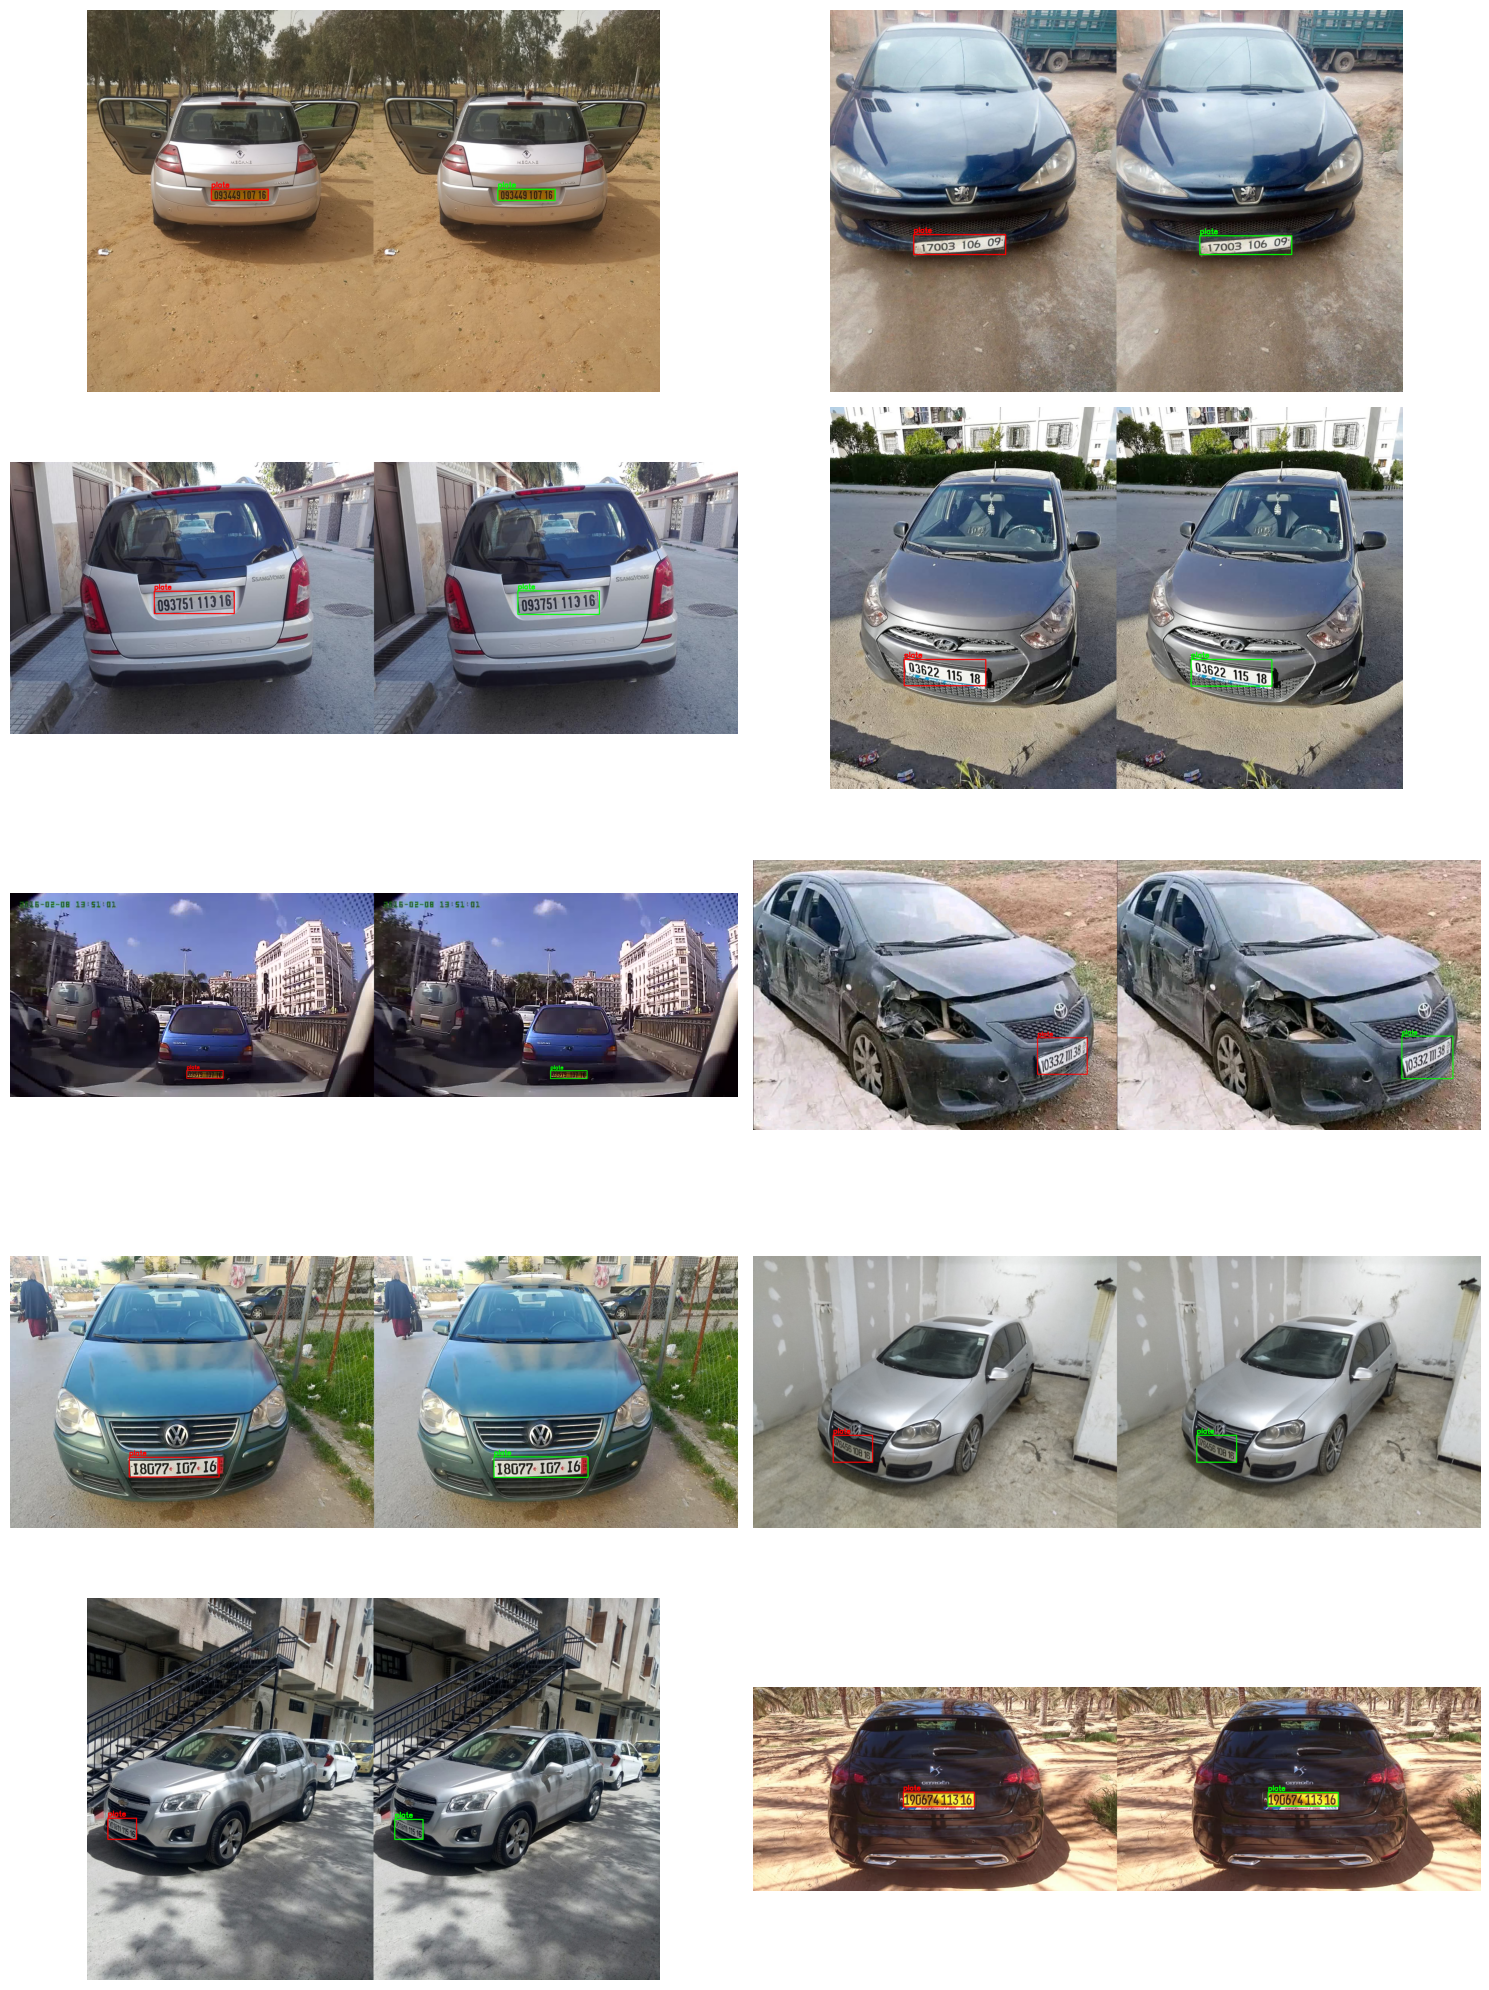

In [ ]:
plt.figure(figsize=(15, 20))

for i, img_path in enumerate(samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # -----------------------
    # PREDICTION (RED)
    # -----------------------
    results = model(img_path)[0]
    pred_img = img.copy()
    pred_img = draw_boxes(pred_img, results.boxes, (255, 0, 0), names)

    # -----------------------
    # GROUND TRUTH (GREEN)
    # -----------------------
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")

    gt_img = img.copy()

    if os.path.exists(label_path):
        h, w, _ = gt_img.shape
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.split())
                cls = int(cls)

                x1 = int((x - bw / 2) * w)
                y1 = int((y - bh / 2) * h)
                x2 = int((x + bw / 2) * w)
                y2 = int((y + bh / 2) * h)

                cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    gt_img,
                    names[cls],
                    (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2,
                )

    # -----------------------
    # DISPLAY SIDE BY SIDE
    # -----------------------
    combined = cv2.hconcat([pred_img, gt_img])

    plt.subplot(5, 2, i + 1)
    plt.imshow(combined)
    plt.axis("off")

plt.tight_layout()
plt.show()